<a href="https://colab.research.google.com/github/SakshamStha47/transit-equity-index-brooklyn/blob/main/notebooks/02_accessibility_determinants_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. SETUP

## 1.1 IMPORTS & ENVIRONMENT CONFIG

In [3]:
!pip install matplotlib-scalebar

In [4]:
!pip install contextily

In [14]:
import geopandas as gpd
import pandas as pd
import zipfile, io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx

data_dir = "/content/drive/MyDrive/Colab Notebooks/Project Dream/Data"
gtfs_dir = "/root/.cache/r5py"

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.argv.extend(["--max-memory", "10G"])

Mounted at /content/drive


## 1.2 MOUNT DRIVE

In [9]:
import shutil
import os

src = "/content/drive/MyDrive/Colab Notebooks/Project Dream/r5py_cache_backup"
dst = os.path.expanduser("~/.cache/r5py")

os.makedirs(dst, exist_ok=True)
shutil.copytree(src, dst, dirs_exist_ok=True)
print("Cache restored from Drive")
print(os.listdir(dst))

Cache restored from Drive
['bronx_bus.zip', 'f7f5e1b757f61243ed56ab15c2d4f1bf05fb6304c54e41f5403a1121f72b3e83.mapdb', 'brooklyn_bus.zip.lock', 'nyc_routable.osm.pbf', 'queens_bus.zip', 'subway.zip', 'nyc_routable.osm.pbf.lock', 'f7f5e1b757f61243ed56ab15c2d4f1bf05fb6304c54e41f5403a1121f72b3e83.transport_network', 'queens_bus.zip.lock', 'r5-v7.5.1-r5py-all.jar', 'manhattan_bus.zip', 'bronx_bus.zip.lock', 'f7f5e1b757f61243ed56ab15c2d4f1bf05fb6304c54e41f5403a1121f72b3e83.mapdb.p', 'brooklyn_bus.zip', 'f7f5e1b757f61243ed56ab15c2d4f1bf05fb6304c54e41f5403a1121f72b3e83.warnings', 'manhattan_bus.zip.lock', 'subway.zip.lock']


# 2. DATA LOADING

## 2.1 Quadrant Data
Stored as `gdf_clean`

In [10]:
gdf_clean = gpd.read_parquet(f"{data_dir}/gdf_clean_quadrant.parquet")

gdf_clean.columns.tolist()

['STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'GEOID',
 'NAME',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry',
 'PC1_Economic_Need',
 'PC2_Mobility_Need',
 'PC3_Employment_Gap',
 'Transit_Equity_Score',
 'reachable_jobs',
 'quadrant']

## 2.2 Subway Stops
(De-duplicated, Brooklyn-clipped)

In [11]:
with zipfile.ZipFile(f"{gtfs_dir}/subway.zip") as z:
    subway_stops_raw = pd.read_csv(io.BytesIO(z.read("stops.txt")))

# Keep only parent stations — removes duplicate N/S platform-level entries
subway_dedup = subway_stops_raw[subway_stops_raw["parent_station"].isna()].copy()

subway_gdf = gpd.GeoDataFrame(
    subway_dedup,
    geometry=gpd.points_from_xy(subway_dedup["stop_lon"], subway_dedup["stop_lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Clip to Brooklyn using gdf_clean's boundary
gdf_3857 = gdf_clean.to_crs(epsg=3857)
brooklyn_boundary = gdf_3857.union_all()
subway_stops_brooklyn = subway_gdf[subway_gdf.within(brooklyn_boundary)].copy()

print(f"Subway stops — raw: {len(subway_stops_raw)}     "
      f"deduplicated: {len(subway_dedup)}     "
      f"Brooklyn-clipped: {len(subway_stops_brooklyn)}")

Subway stops — raw: 1488     deduplicated: 496     Brooklyn-clipped: 167


## 2.3 Bus Stop
(De-duplicated, Brooklyn-clipped)

In [12]:
bus_files = ["bronx_bus.zip", "brooklyn_bus.zip", "queens_bus.zip", "manhattan_bus.zip"]

bus_stops_list = []
for bus_file in bus_files:
    with zipfile.ZipFile(f"{gtfs_dir}/{bus_file}") as z:
        stops = pd.read_csv(io.BytesIO(z.read("stops.txt")))
        bus_stops_list.append(stops)

bus_stops_raw = pd.concat(bus_stops_list, ignore_index=True)

# Deduplicate — the same stop can appear in multiple borough feeds (e.g. cross-border routes)
bus_dedup = bus_stops_raw.drop_duplicates(subset="stop_id").copy()

bus_gdf = gpd.GeoDataFrame(
    bus_dedup,
    geometry=gpd.points_from_xy(bus_dedup["stop_lon"], bus_dedup["stop_lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

bus_stops_brooklyn = bus_gdf[bus_gdf.within(brooklyn_boundary)].copy()

print(f"Bus stops — raw (all 4 feeds): {len(bus_stops_raw)}    "
      f"deduplicated: {len(bus_dedup)}    "
      f"Brooklyn-clipped: {len(bus_stops_brooklyn)}")

Bus stops — raw (all 4 feeds): 9665    deduplicated: 9563    Brooklyn-clipped: 3826


## 2.4 Overlay Bus-stops and Subway-stops on top of Qudrant Map

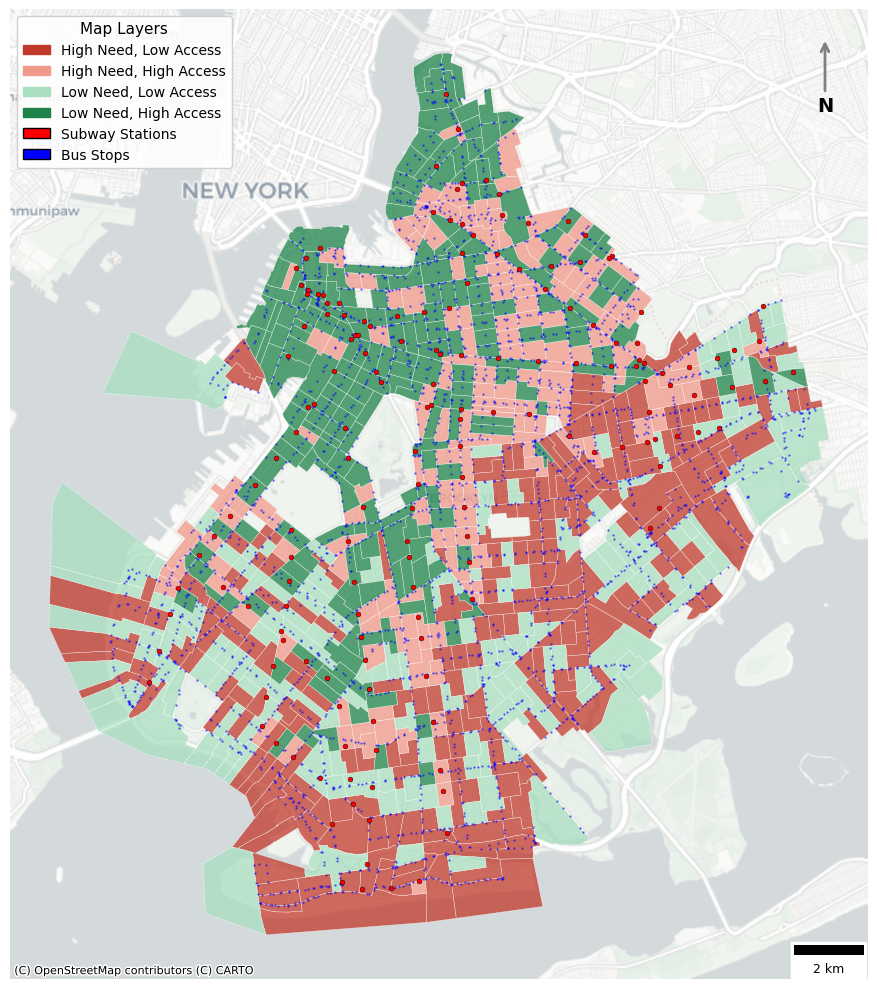

In [15]:
fig, ax = plt.subplots(figsize=(12, 10))

# Quadrants

quadrant_colors = {
    "High Need, Low Access": "#c0392b",       # strong red
    "High Need, High Access": "#f1998a",      # light salmon pink
    "Low Need, Low Access": "#a9dfbf",        # light mint green
    "Low Need, High Access": "#1e8449",       # strong green
}

for quadrant, color in quadrant_colors.items():
    gdf_plot[gdf_plot["quadrant"] == quadrant].plot(
        ax=ax,
        color=color,
        edgecolor="white",
        linewidth=0.3,
        alpha=0.75
    )

# Bus stops (plot first)
bus_stops_brooklyn.plot(
    ax=ax,
    color="blue",
    markersize=2,
    marker=".",
    alpha=0.5,
    zorder=4
)

# Subway stations (plot on top)
subway_stops_brooklyn.plot(
    ax=ax,
    color="red",
    markersize=12,
    marker="o",
    edgecolor="black",
    linewidth=0.3,
    zorder=5
)

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=12
)

# Legend
patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in quadrant_colors.items()
]

patches.append(
    mpatches.Patch(facecolor="red", edgecolor="black",
                   label="Subway Stations")
)

patches.append(
    mpatches.Patch(facecolor="blue", edgecolor="black",
                   label="Bus Stops")
)

ax.legend(
    handles=patches,
    title="Map Layers",
    loc="upper left",
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9
)

# Scale bar
ax.add_artist(
    ScaleBar(
        1,
        units="m",
        location="lower right",
        length_fraction=0.2,
        font_properties={"size": 9}
    )
)

# North arrow
ax.annotate(
    "N",
    xy=(0.95, 0.97),
    xycoords="axes fraction",
    fontsize=14,
    ha="center",
    va="top",
    fontweight="bold",
    xytext=(0.95, 0.91),
    arrowprops=dict(
        arrowstyle="->",
        color="grey",
        lw=2
    )
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Project Dream/Data/Figure3_with_subway_and_bus.jpeg",
    dpi=900,
    bbox_inches="tight",
    format="jpeg"
)

plt.show()

# 3. VARIABLE CALCULATION

## Import Centroid and Job data

In [16]:
# Import gpd with centroid and job counts
tract_centroid = gpd.read_parquet("/content/drive/MyDrive/Colab Notebooks/Project Dream/Data/tract_centroid.parquet")

print(tract_centroid)

        tract_id                          CENTROID  total_jobs
0    36047000700  POINT (-8237346.589 4967068.789)       859.0
1    36047000900  POINT (-8236707.434 4966976.321)     12596.0
2    36047001100  POINT (-8236274.059 4967206.781)     21611.0
3    36047001300  POINT (-8236346.406 4967841.747)      6416.0
4    36047002000   POINT (-8239415.372 4960565.55)      1496.0
..           ...                               ...         ...
800  36047062000  POINT (-8231623.084 4950466.899)       675.0
801  36047080800   POINT (-8230905.973 4961924.63)      7479.0
802  36047123700  POINT (-8232826.684 4967713.033)      3480.0
803  36047021100  POINT (-8234517.125 4967763.989)      1223.0
804  36047048500  POINT (-8230556.334 4969343.202)      7023.0

[805 rows x 3 columns]


## 3.1 Distance to nearest subway station

In [17]:
nearest_subway = gpd.sjoin_nearest(
    tract_centroid,
    subway_stops_brooklyn[["geometry"]],
    how="left",
    distance_col="dist_subway_m"
)

tract_centroid["dist_subway_m"] = nearest_subway["dist_subway_m"]

## 3.2 Distance to nearest bus stop

In [18]:
nearest_bus = gpd.sjoin_nearest(
    tract_centroid,
    bus_stops_brooklyn[["geometry"]],
    how="left",
    distance_col="dist_bus_m"
)

tract_centroid["dist_bus_m"] = nearest_bus["dist_bus_m"]

## 3.3 Number of subway stations within 1km

In [19]:
centroid_buffer = tract_centroid.copy()
centroid_buffer["buffer_1km"] = centroid_buffer.geometry.buffer(1000)
centroid_buffer = centroid_buffer.set_geometry("buffer_1km")

subway_join = gpd.sjoin(
    centroid_buffer,
    subway_stops_brooklyn[["geometry"]],
    predicate="contains",
    how="left"
)

subway_counts = subway_join.groupby(subway_join.index)["index_right"].count()

tract_centroid["subway_1km"] = (
    subway_counts.reindex(tract_centroid.index)
    .fillna(0)
    .astype(int)
)

## 3.4 Number of bus stations within 1km

In [20]:
bus_join = gpd.sjoin(
    centroid_buffer,
    bus_stops_brooklyn[["geometry"]],
    predicate="contains",
    how="left"
)

bus_counts = bus_join.groupby(bus_join.index)["index_right"].count()

tract_centroid["bus_stops_1km"] = (
    bus_counts.reindex(tract_centroid.index)
    .fillna(0)
    .astype(int)
)

## 3.5 Distance to manhattan CBD

In [21]:

import geopandas as gpd
from shapely.geometry import Point

# Reproject to a metric CRS if not already
gdf_proj = gdf_clean.to_crs(epsg=32618)
gdf_proj["centroid"] = gdf_proj.geometry.centroid

# Manhattan CBD reference point (Times Square / Midtown "Manhattan's Business Core")
cbd_point = gpd.GeoSeries([Point(-73.9857, 40.7580)], crs="EPSG:4326").to_crs(epsg=32618).iloc[0]

gdf_proj["dist_cbd_m"] = gdf_proj["centroid"].distance(cbd_point)

cbd_dist = gdf_proj[["GEOID", "dist_cbd_m"]].rename(columns={"GEOID": "tract_id"})

tract_centroid = tract_centroid.drop(columns=[c for c in ["dist_cbd_m"] if c in tract_centroid.columns])

cbd_dist = gdf_proj[["GEOID", "dist_cbd_m"]].rename(columns={"GEOID": "tract_id"})
tract_centroid = tract_centroid.merge(cbd_dist, on="tract_id", how="left")

## 3.6 Population density

In [28]:
poverty_merged = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project Dream/Data/poverty_merged.csv')

In [30]:
# Remove any previously-merged columns before re-merging (safe to run even if they don't exist)
cols_to_drop = ["total_population", "ALAND", "pop_density", ""]
tract_centroid = tract_centroid.drop(columns=[c for c in cols_to_drop if c in tract_centroid.columns])

# Ensure tract_id in tract_centroid is string type for consistent merging
tract_centroid["tract_id"] = tract_centroid["tract_id"].astype(str)

# 1. Bring in total population from poverty_merged
pop_data = poverty_merged[["GEOID", "B17017_001E"]].rename(
    columns={"GEOID": "tract_id", "B17017_001E": "total_population"}
)
# Ensure tract_id in pop_data is string type
pop_data["tract_id"] = pop_data["tract_id"].astype(str)
tract_centroid = tract_centroid.merge(pop_data, on="tract_id", how="left")

# 2. Bring in land area from gdf_clean (needed to compute density)
land_area = gdf_clean[["GEOID", "ALAND"]].rename(columns={"GEOID": "tract_id"})
# Ensure tract_id in land_area is string type
land_area["tract_id"] = land_area["tract_id"].astype(str)
tract_centroid = tract_centroid.merge(land_area, on="tract_id", how="left")

# 3. Compute population density (people per sq km)
tract_centroid["pop_density"] = tract_centroid["total_population"] / (tract_centroid["ALAND"] / 1_000_000)

## 3.7 Combining all data

In [41]:
print(tract_centroid.columns.tolist())

['tract_id', 'CENTROID', 'total_jobs', 'dist_subway_m', 'dist_bus_m', 'subway_1km', 'bus_stops_1km', 'dist_cbd_m', 'total_population', 'ALAND', 'pop_density']


In [39]:
new_columns_only = tract_centroid[[
    "tract_id", "dist_subway_m", "dist_bus_m", "subway_1km", "bus_stops_1km",
    "total_population", "pop_density", "dist_cbd_m"
]].rename(columns={"tract_id": "GEOID"})

gdf_clean = gdf_clean.merge(new_columns_only, on="GEOID", how="left")

print(gdf_clean.columns.tolist())

['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'PC1_Economic_Need', 'PC2_Mobility_Need', 'PC3_Employment_Gap', 'Transit_Equity_Score', 'reachable_jobs', 'quadrant', 'dist_subway_m', 'dist_bus_m', 'subway_1km', 'bus_stops_1km', 'total_population', 'pop_density', 'dist_cbd_m']


In [40]:
print(gdf_clean.head())

  STATEFP COUNTYFP TRACTCE        GEOID NAME         NAMELSAD  MTFCC FUNCSTAT  \
0      36      047  000700  36047000700    7   Census Tract 7  G5020        S   
1      36      047  000900  36047000900    9   Census Tract 9  G5020        S   
2      36      047  001100  36047001100   11  Census Tract 11  G5020        S   
3      36      047  001300  36047001300   13  Census Tract 13  G5020        S   
4      36      047  002000  36047002000   20  Census Tract 20  G5020        S   

    ALAND  AWATER  ... Transit_Equity_Score reachable_jobs  \
0  176774       0  ...            -2.128103      2157255.0   
1  163469       0  ...            -1.886500      2949123.0   
2  168507       0  ...            -1.519720      3007472.0   
3  293167       0  ...            -0.417870      2538889.0   
4  154138       0  ...            -0.288832       391772.0   

                quadrant  dist_subway_m  dist_bus_m  subway_1km  \
0  Low Need, High Access     670.779757  263.914849           4   
1  Low

In [42]:
# Saving gdf_clean which now has all the calculations we've done in one single variable.

gdf_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/Project Dream/Data/gdf_clean_full_variables.parquet")
print("Saved gdf_clean with all variables to Drive")

Saved gdf_clean with all variables to Drive


# 4. STATISTICAL ANALYSIS
Use statistical methods to find out which variable has the highest influence on job reachability.

## 4.1 Mann-WHitney U + Rank-Biserial Correlation

In [43]:
!pip install pingouin -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 13.2 MB/s eta 0:00:00


In [44]:
import pingouin as pg
import pandas as pd

low_access = gdf_clean[gdf_clean["quadrant"] == "High Need, Low Access"]
high_access = gdf_clean[gdf_clean["quadrant"] == "High Need, High Access"]

variables_to_test = [
    "dist_subway_m", "subway_1km", "dist_bus_m", "bus_stops_1km",
    "dist_cbd_m", "pop_density"
]

results = []
for var in variables_to_test:
    test = pg.mwu(low_access[var].dropna(), high_access[var].dropna())
    results.append({
        "variable": var,
        "low_access_median": low_access[var].median(),
        "high_access_median": high_access[var].median(),
        "p_value": test["p_val"].values[0],
        "rank_biserial_correlation": test["RBC"].values[0],
    })

results_df = pd.DataFrame(results).sort_values("rank_biserial_correlation", key=abs, ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
print(results_df)

        variable  low_access_median  high_access_median     p_value  \
4     dist_cbd_m            15131.9             10834.1 6.28983e-34   
0  dist_subway_m            873.405             406.619 7.55952e-31   
1     subway_1km                  1                   2 1.17455e-20   
5    pop_density             6050.1             9542.41 3.58705e-18   
3  bus_stops_1km                 41                  52 4.12643e-12   
2     dist_bus_m            176.784             161.799 0.000764387   

   rank_biserial_correlation  
4                    0.72154  
0                   0.686213  
1                  -0.540322  
5                  -0.516462  
3                  -0.411876  
2                        0.2  


All six variables were statistically significant, but distance to CBD (RBC=0.72) and distance to subway (RBC=0.69) are clearly the two strongest, with subway density, population density, and bus variables trailing behind.

## 4.2 Nested Regression
We see that distance to CBD has the biggest effect on job reachability. Distance to CDB is more of a geographic than a variable that can be moved around easily. So now we test if job reachability relies solely on distance to CBD or if the other variables add any explanatory power beyond simple geography.

We create two models and compare them:

Model 1: Job Reachability ~ Distance to CBD
Model 2: Job Reachability ~ Distance to CBD + Other variables

In [45]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df_reg = gdf_clean[[
    "reachable_jobs", "dist_cbd_m", "dist_subway_m",
    "subway_1km", "dist_bus_m", "bus_stops_1km", "pop_density"
]].dropna().copy()

# Model 1: geography only
model1 = smf.ols("reachable_jobs ~ dist_cbd_m", data=df_reg).fit()

# Model 2: geography + transit + density
model2 = smf.ols(
    "reachable_jobs ~ dist_cbd_m + dist_subway_m + subway_1km + dist_bus_m + bus_stops_1km + pop_density",
    data=df_reg
).fit()

print("MODEL 1 (Distance to CBD only)")
print(f"Adjusted R²: {model1.rsquared_adj:.3f}, AIC: {model1.aic:.1f}")

print("\nMODEL 2 (+ transit + density variables)")
print(f"Adjusted R²: {model2.rsquared_adj:.3f}, AIC: {model2.aic:.1f}")

anova_results = anova_lm(model1, model2)
print("\nNested model comparison (F-test):")
print(anova_results)

print("\nFull Model 2 summary:")
print(model2.summary())

MODEL 1 (Distance to CBD only)
Adjusted R²: 0.623, AIC: 22390.3

MODEL 2 (+ transit + density variables)
Adjusted R²: 0.718, AIC: 22171.6

Nested model comparison (F-test):
   df_resid         ssr  df_diff     ss_diff       F      Pr(>F)
0       772 1.64932e+14        0         NaN     NaN         NaN
1       767 1.22737e+14        5 4.21951e+13 52.7364 4.53591e-47

Full Model 2 summary:
                            OLS Regression Results                            
Dep. Variable:         reachable_jobs   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     328.5
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          4.42e-208
Time:                        15:24:24   Log-Likelihood:                -11079.
No. Observations:                 774   AIC:                         2.217e+04
Df Residuals:                     767   BIC:            

But look closely at the individual coefficients — this is the important nuance

* dist_subway_m (distance to nearest station): p = 0.303 — NOT significant
* subway_1km (number of stations within 1km): p < 0.001 — highly significant

This means: once you know how many subway stations are clustered near a tract, knowing the exact distance to the single nearest one adds nothing extra. These two variables are capturing overlapping information (a tract close to one station is usually also close to several), and in this "horse race" between them, station density wins, not proximity to the nearest single station.

### Findings: *"it's not simply about having one subway station nearby — what predicts job accessibility is having a cluster of multiple subway stations within reach."*

## 4.4 VIF Check + Supression Effect Diagnosis

In [46]:
# Checking for multi-collinearity between dist_subway_m and subway_1km

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_reg[["dist_cbd_m", "dist_subway_m", "subway_1km", "dist_bus_m", "bus_stops_1km", "pop_density"]]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

        variable     VIF
0          const 52.1496
1     dist_cbd_m 1.43646
2  dist_subway_m   1.729
3     subway_1km 1.72225
4     dist_bus_m 1.27408
5  bus_stops_1km 1.53568
6    pop_density 1.38804


The VIF of `dist_subway_m` -> 1.729 and `subway_1km` -> 1.722 are very similar, meaning there is a a suppression effect, not multicollinearity — the two subway variables were too intertwined to show independent effects together, but each was strong and significant on its own.

## 4.5 Logistic Regression

In [47]:
import statsmodels.formula.api as smf
import numpy as np
from sklearn.preprocessing import StandardScaler

# Restrict to High-Need tracts only
high_need = gdf_clean[gdf_clean["quadrant"].isin(["High Need, Low Access", "High Need, High Access"])].copy()
high_need["high_access"] = (high_need["quadrant"] == "High Need, High Access").astype(int)

print(f"Sample size: {len(high_need)}")
print(high_need["high_access"].value_counts())

# Prepare predictors
predictors = ["dist_cbd_m", "dist_subway_m", "subway_1km", "dist_bus_m", "bus_stops_1km", "pop_density"]
df_logit = high_need[["high_access"] + predictors].dropna().copy()

# Standardize predictors so coefficients/odds ratios are directly comparable in size
scaler = StandardScaler()
df_logit_std = df_logit.copy()
df_logit_std[predictors] = scaler.fit_transform(df_logit[predictors])

# Fit logistic regression
logit_model = smf.logit(
    "high_access ~ dist_cbd_m + dist_subway_m + subway_1km + dist_bus_m + bus_stops_1km + pop_density",
    data=df_logit_std
).fit()

print(logit_model.summary())

# Odds ratios (per 1 standard deviation change) — easier to interpret than raw log-odds coefficients
odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())
conf_int.columns = ["OR_2.5%", "OR_97.5%"]
odds_summary = pd.concat([odds_ratios.rename("odds_ratio"), conf_int], axis=1)
print("\nOdds ratios (per 1 SD increase):")
print(odds_summary)

Sample size: 387
high_access
0    222
1    165
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.274588
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:            high_access   No. Observations:                  387
Model:                          Logit   Df Residuals:                      380
Method:                           MLE   Df Model:                            6
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                  0.5975
Time:                        15:35:43   Log-Likelihood:                -106.27
converged:                       True   LL-Null:                       -264.03
Covariance Type:            nonrobust   LLR p-value:                 3.820e-65
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.2939     

In [48]:
import pandas as pd

variance_comparison = pd.DataFrame({
    "variable": ["subway_1km (count)", "dist_subway_m (distance)"],
    "full_sample_std": [
        gdf_clean["subway_1km"].std(),
        gdf_clean["dist_subway_m"].std()
    ],
    "restricted_sample_std": [
        high_need["subway_1km"].std(),
        high_need["dist_subway_m"].std()
    ],
})

variance_comparison["pct_reduction"] = (
    (variance_comparison["full_sample_std"] - variance_comparison["restricted_sample_std"])
    / variance_comparison["full_sample_std"] * 100
)

pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(variance_comparison)

                   variable  full_sample_std  restricted_sample_std  \
0        subway_1km (count)            1.834                  1.624   
1  dist_subway_m (distance)            752.3                  748.9   

   pct_reduction  
0          11.48  
1         0.4496  


the same suppression issue (quasi-separation warning). Running distance and density separately (not together) gave clean, stable, significant results for each.

"Among high-need tracts, the spread of station density is compressed relative to the full Brooklyn sample, while the spread of distance to the nearest station remains just as wide. This reduced variance likely limits density's ability to serve as a stable, independent statistical predictor within this subsample, even though it remains meaningfully different between the two groups on its own (Mann-Whitney). Distance to the nearest station, having retained its full range of variation, ends up carrying more of the explanatory weight when both variables are forced into the same model."

## 4.6 Convergent Evidence - Random Forest + Standardized Coefficients

Ran Random Forest permutation importance and standalone standardized logistic coefficients, compared against the original Mann-Whitney rankings.

### 4.6.1 Random Forest classifier + feature importance (on the same restricted 387-tract sample)

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

predictors = ["dist_cbd_m", "dist_subway_m", "subway_1km", "dist_bus_m", "bus_stops_1km", "pop_density"]

X = high_need[predictors].dropna()
y = high_need.loc[X.index, "high_access"]

rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=5)
rf.fit(X, y)

# Quick check the model is actually predictive, not just fitting noise
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"Cross-validated accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Built-in importance (biased toward continuous/high-cardinality variables — use as a first look only)
builtin_importance = pd.DataFrame({
    "variable": predictors,
    "builtin_importance": rf.feature_importances_
}).sort_values("builtin_importance", ascending=False)

print("\nBuilt-in Random Forest importance:")
print(builtin_importance)

# Permutation importance — more reliable, measures actual drop in accuracy when a variable is shuffled
perm_result = permutation_importance(rf, X, y, n_repeats=30, random_state=42)

perm_importance = pd.DataFrame({
    "variable": predictors,
    "permutation_importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("permutation_importance", ascending=False)

print("\nPermutation importance (more reliable):")
print(perm_importance)

Cross-validated accuracy: 0.843 (+/- 0.050)

Built-in Random Forest importance:
        variable  builtin_importance
0     dist_cbd_m              0.3805
1  dist_subway_m              0.2858
5    pop_density              0.1197
2     subway_1km             0.09997
4  bus_stops_1km             0.06553
3     dist_bus_m             0.04858

Permutation importance (more reliable):
        variable  permutation_importance      std
0     dist_cbd_m                  0.1972   0.0192
1  dist_subway_m                  0.1499  0.01255
3     dist_bus_m                 0.01731 0.004067
5    pop_density                 0.01593 0.005858
4  bus_stops_1km                0.006891 0.004022
2     subway_1km                 0.00646 0.003515


### 4.6.2 Standardized single-variable logistic coefficients

avoids the suppression-effect instability by testing each variable alone, same spirit as your Mann-Whitney table but continuous/model-based

In [50]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

df_std = high_need[["high_access"] + predictors].dropna().copy()
df_std[predictors] = StandardScaler().fit_transform(df_std[predictors])

univariate_results = []
for var in predictors:
    model = smf.logit(f"high_access ~ {var}", data=df_std).fit(disp=0)
    univariate_results.append({
        "variable": var,
        "standardized_coef": model.params[var],
        "p_value": model.pvalues[var]
    })

univariate_df = pd.DataFrame(univariate_results).sort_values("standardized_coef", key=abs, ascending=False)
print("\nStandardized single-variable logistic coefficients:")
print(univariate_df)


Standardized single-variable logistic coefficients:
        variable  standardized_coef   p_value
1  dist_subway_m             -3.073  9.33e-16
0     dist_cbd_m             -1.965 8.567e-22
2     subway_1km              1.099 7.231e-15
5    pop_density               1.04 3.459e-13
4  bus_stops_1km             0.8115 2.232e-11
3     dist_bus_m            -0.4328 0.0001955


### 4.6.3 Put all three rankings side by side for
the final comparison

In [51]:
final_comparison = (
    permutation_importance := perm_importance[["variable", "permutation_importance"]]
).merge(
    univariate_df[["variable", "standardized_coef"]], on="variable"
).merge(
    results_df.rename(columns={"rank_biserial_correlation": "RBC"})[["variable", "RBC"]] if "dist_subway_m" in results_df["variable"].values else pd.DataFrame({"variable": predictors}),
    on="variable", how="left"
)

print("\n=== FINAL CONVERGENT EVIDENCE TABLE ===")
print(final_comparison.sort_values("permutation_importance", ascending=False))


=== FINAL CONVERGENT EVIDENCE TABLE ===
        variable  permutation_importance  standardized_coef     RBC
0     dist_cbd_m                  0.1972             -1.965  0.7215
1  dist_subway_m                  0.1499             -3.073  0.6862
2     dist_bus_m                 0.01731            -0.4328     0.2
3    pop_density                 0.01593               1.04 -0.5165
4  bus_stops_1km                0.006891             0.8115 -0.4119
5     subway_1km                 0.00646              1.099 -0.5403


### The three independent statistical approaches agree that subway proximity (and general Manhattan proximity) are the dominant, real drivers of the accessibility gap among high-need tracts — not density, not bus access. This gives your microtransit intervention (which targets first-mile subway access specifically) a solid empirical foundation, rather than resting on visual pattern alone.